In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import make_moons, make_s_curve

from Autoencoders import ConformalAutoencoder
from helper import load_optimizer_and_scheduler, save_optimizer_and_scheduler
from data import make_half_sphere
from metrics import evaluate_conformality

random_state = 42
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
class Encoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super(Encoder, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, latent_dim)
        )
    
    def forward(self, x):
        return self.fc(x)

class Decoder(nn.Module):
    def __init__(self, latent_dim, output_dim):
        super(Decoder, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, output_dim)
        )
    
    def forward(self, z):
        return self.fc(z)

In [3]:
data, labels = make_half_sphere(n_samples=2000, noise=0.05, random_state=random_state)
data = torch.tensor(data, dtype=torch.float32).to(device)
val_data, val_labels = make_half_sphere(n_samples=1000, noise=0.05, random_state=random_state+1)
val_data = torch.tensor(val_data, dtype=torch.float32).to(device)

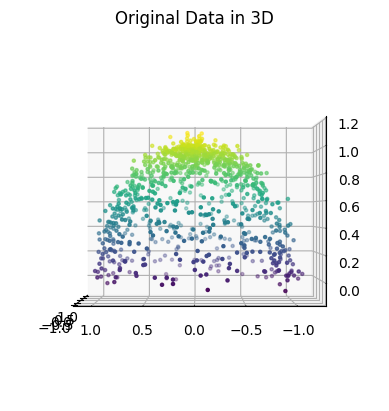

In [4]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(data[:, 0].cpu(), data[:, 1].cpu(), data[:, 2].cpu(), c=labels, s=5)
ax.set_title("Original Data in 3D")
ax.view_init(0, 180, 0)
plt.show()

In [5]:
# define model parameters
latent_dim = 2
input_dim = data.shape[1]
output_dim = data.shape[1]
batch_size = 64

train_dataloader = torch.utils.data.DataLoader(data, batch_size=batch_size, shuffle=True)
val_dataloader = torch.utils.data.DataLoader(val_data, batch_size=batch_size, shuffle=False)

In [6]:
lambda_isos = np.logspace(-3, 3, 10)

In [9]:
from metrics import conformality_cosine_loss

In [14]:
num_epochs = 100
# train same model multiple times to average results
num_models = 4

recon_errors = []
regularization_errors = []


for i, lambda_iso in enumerate(lambda_isos):
    recon_error = 0
    regularization = 0
    for j in range(num_models):
        print(f"Training model {j+1}/{num_models} with lambda_iso={lambda_iso:.3f}")
        
        encoder = Encoder(input_dim, latent_dim).to(device)
        decoder = Decoder(latent_dim, output_dim).to(device)
        model = ConformalAutoencoder(encoder, decoder, lambda_conf=lambda_iso).to(device)
        model.conformality_loss = conformality_cosine_loss

        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=100, gamma=0.5)

        # Train the model
        model.train_model(train_dataloader, val_dataloader, batch_size=batch_size, epochs=num_epochs,
                          optimizer=optimizer, scheduler=scheduler, verbose=True)

        # Save the model and optimizer state
        model_path = f"models/conformal_angle_cos_autoencoder_half_sphere/lambda_{lambda_iso:.3f}_model_{j+1}.pth"
        torch.save(model.state_dict(), model_path)
        print(f"Model {j+1}/{num_models} with lambda_iso={lambda_iso:.3f} trained and saved.")

        # evaluation
        model.eval()
        encoded_data = model.encode(val_data)
        reconstruction = model.decode(encoded_data)
        
        recon_error += nn.MSELoss()(reconstruction, val_data).item()

        regularization += model.conformality_loss(model.decoder, encoded_data).item()
    
    recon_errors.append(recon_error/ num_models)
    regularization_errors.append(regularization/num_models)
    

Training model 1/4 with lambda_iso=0.001
Epoch [100/100], Loss: 0.00101906, Reconstruction Loss: 0.00100600, Conformal Loss: 0.01305741
Epoch [100/100], Validation Loss: 0.00115722, Reconstruction Loss: 0.00114298, Conformal Loss: 0.01423797
Model 1/4 with lambda_iso=0.001 trained and saved.
Training model 2/4 with lambda_iso=0.001
Epoch [100/100], Loss: 0.00107573, Reconstruction Loss: 0.00106110, Conformal Loss: 0.01463601
Epoch [100/100], Validation Loss: 0.00126670, Reconstruction Loss: 0.00125125, Conformal Loss: 0.01545339
Model 2/4 with lambda_iso=0.001 trained and saved.
Training model 3/4 with lambda_iso=0.001
Epoch [100/100], Loss: 0.00105666, Reconstruction Loss: 0.00104201, Conformal Loss: 0.01464509
Epoch [100/100], Validation Loss: 0.00123362, Reconstruction Loss: 0.00121979, Conformal Loss: 0.01382188
Model 3/4 with lambda_iso=0.001 trained and saved.
Training model 4/4 with lambda_iso=0.001
Epoch [100/100], Loss: 0.00091825, Reconstruction Loss: 0.00090764, Conformal Lo

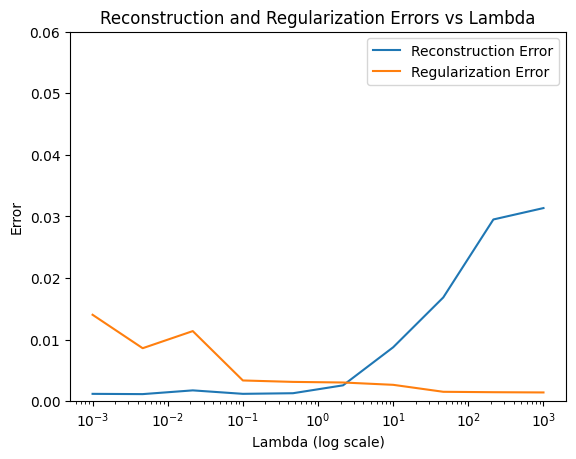

In [15]:
plt.plot(lambda_isos, recon_errors, label='Reconstruction Error')
plt.plot(lambda_isos, regularization_errors, label='Regularization Error')
plt.ylim(0, 0.06)
plt.xscale('log')
plt.xlabel('Lambda (log scale)')
plt.ylabel('Error')
plt.title('Reconstruction and Regularization Errors vs Lambda')
plt.legend()
plt.show()

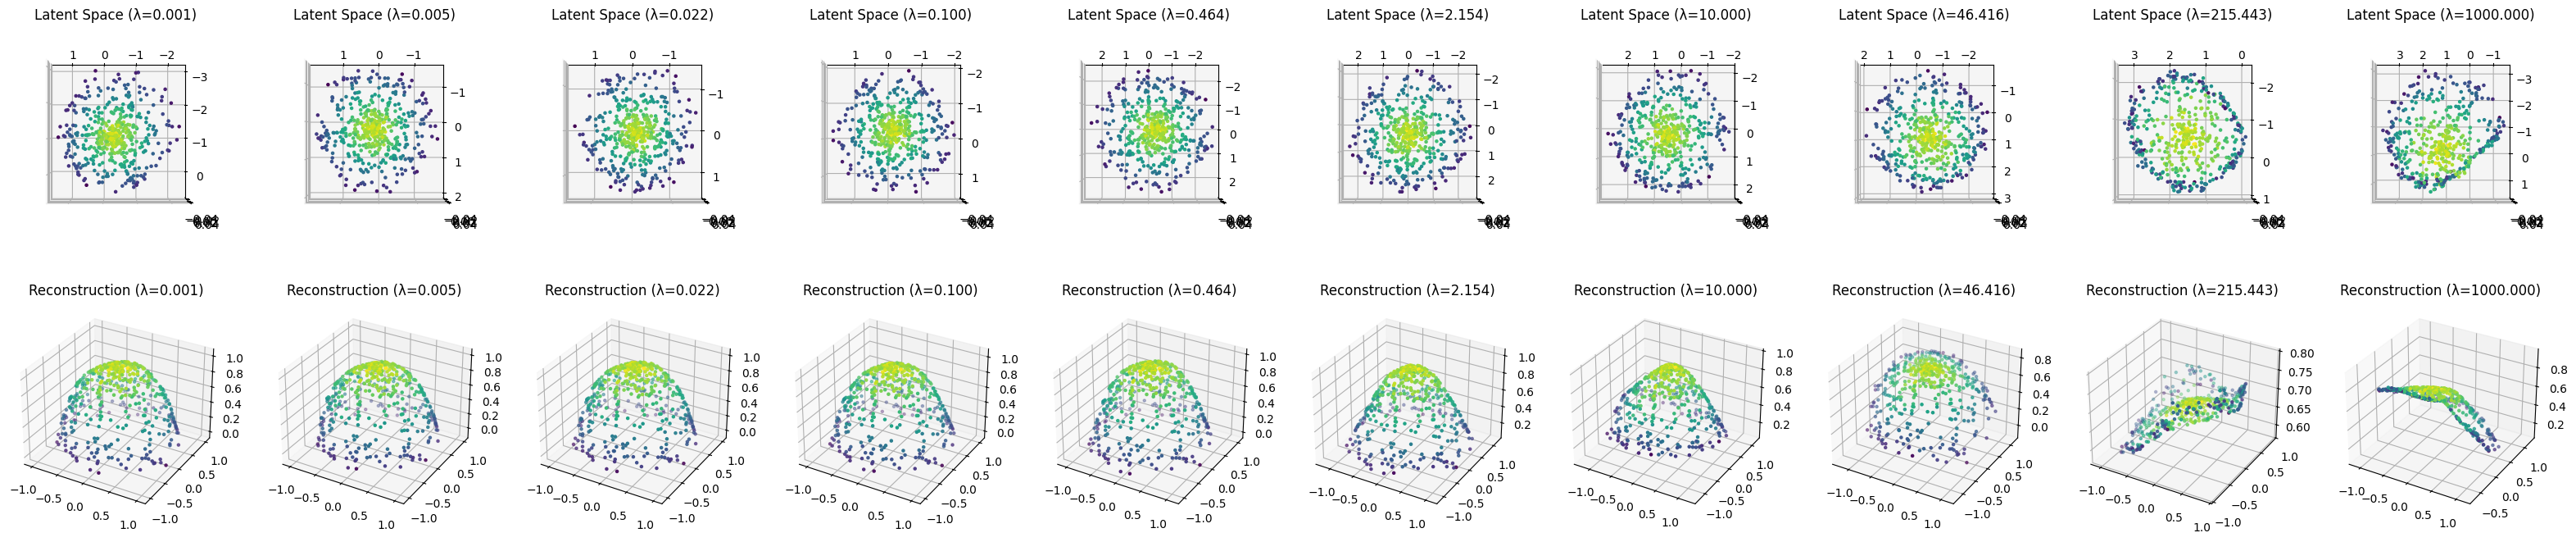

In [17]:
# plot samples and latent space at different lambdas
fig, axs = plt.subplots(2, 10, figsize=(40, 8), subplot_kw=dict(projection='3d'))
for i, lambda_iso in enumerate(lambda_isos):
    model_path = f"models/conformal_angle_cos_autoencoder_half_sphere/lambda_{lambda_iso:.3f}_model_2.pth"
    model = ConformalAutoencoder(Encoder(input_dim, latent_dim), Decoder(latent_dim, output_dim), lambda_conf=lambda_iso).to(device)
    model.load_state_dict(torch.load(model_path))
    
    model.eval()
    with torch.no_grad():
        encoded_data = model.encode(val_data)
        reconstruction = model.decode(encoded_data)

    axs[0, i].scatter(encoded_data[:, 0].cpu(), encoded_data[:, 1].cpu(), c=val_labels, s=5)
    axs[0, i].set_title(f'Latent Space (λ={lambda_iso:.3f})')
    axs[0, i].view_init(90, 90, 0)
    # axs[0, i].set_xticks([])
    # axs[0, i].set_yticks([])
    #plot 3d data
    axs[1, i].scatter(reconstruction[:, 0].cpu(), reconstruction[:, 1].cpu(), reconstruction[:, 2].cpu(), c=val_labels, s=5)
    axs[1, i].set_title(f'Reconstruction (λ={lambda_iso:.3f})')

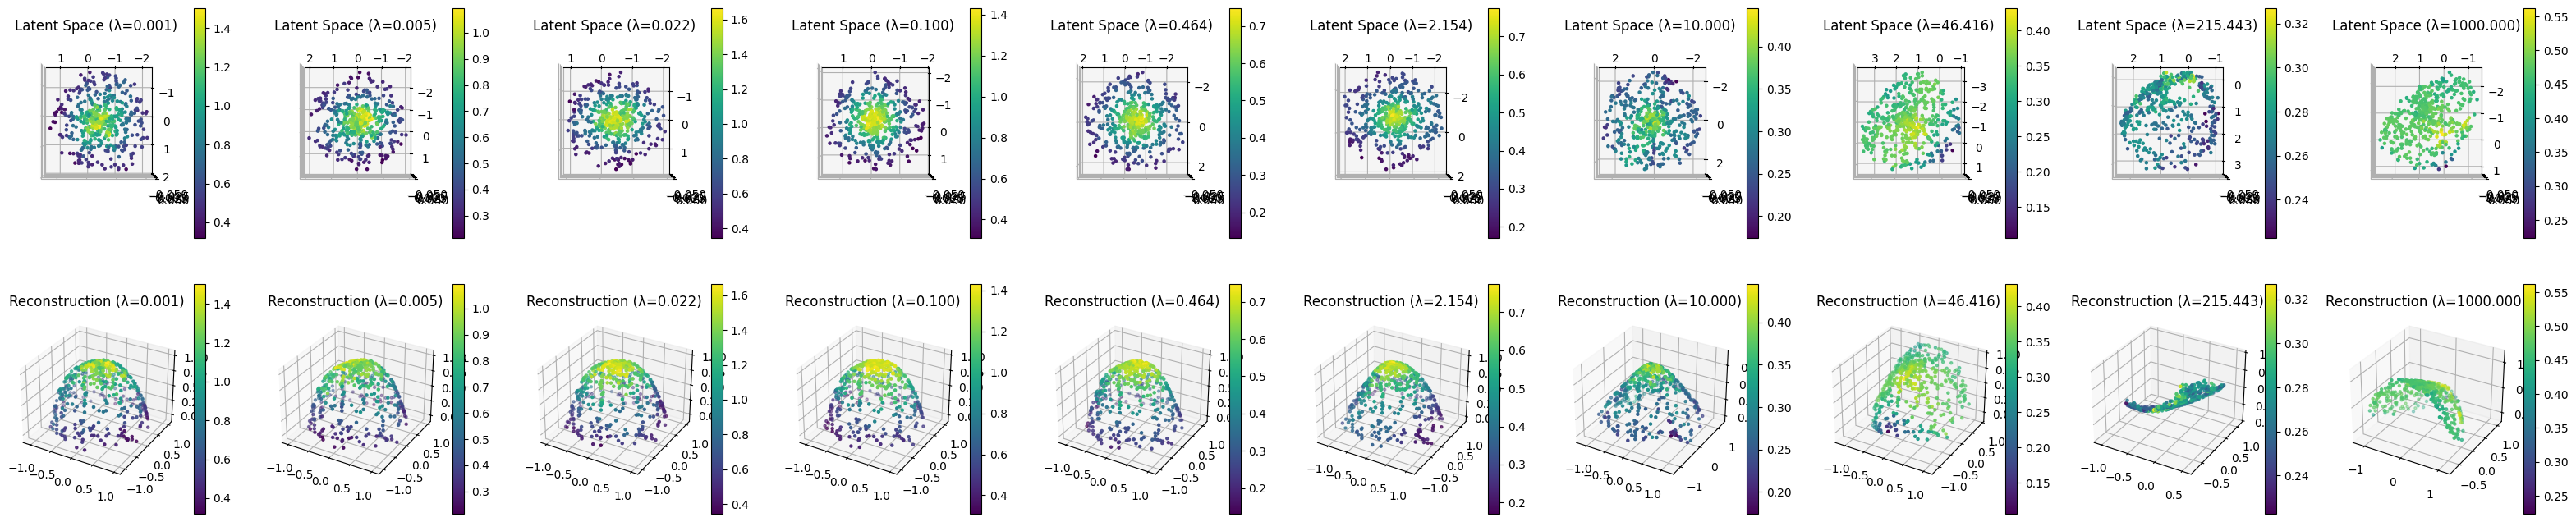

In [18]:
fig, axs = plt.subplots(2, 10, figsize=(40, 8), subplot_kw=dict(projection='3d'))
for i, lambda_iso in enumerate(lambda_isos):
    model_path = f"models/conformal_angle_cos_autoencoder_half_sphere/lambda_{lambda_iso:.3f}_model_1.pth"
    model = ConformalAutoencoder(Encoder(input_dim, latent_dim), Decoder(latent_dim, output_dim), lambda_conf=lambda_iso).to(device)
    model.load_state_dict(torch.load(model_path))
    
    model.eval()
    with torch.no_grad():
        encoded_data = model.encode(val_data)
        reconstruction = model.decode(encoded_data)

    trace_vals = np.zeros_like(encoded_data[:, 0].cpu())
    for j, z in enumerate(encoded_data):
        z = z.unsqueeze(0)  # Add batch dimension
        y = model.decode(z)  # Decode to get reconstruction
        y = y.squeeze(0)  # Remove batch dimension

        # Compute the Jacobian J of the decoder at point z
        J = torch.autograd.functional.jacobian(model.decode, z)[0,:,0,:]

        # Compute the trace of J^T J
        JtJ = J.T @ J
        trace_JtJ = torch.trace(JtJ)

        # Store the trace value as a label for the point
        trace_vals[j] = trace_JtJ.item() / JtJ.shape[0]  # Normalize by the number of dimensions

    p = axs[0, i].scatter(encoded_data[:, 0].cpu(), encoded_data[:, 1].cpu(), c=trace_vals, s=5)
    plt.colorbar(p)
    axs[0, i].set_title(f'Latent Space (λ={lambda_iso:.3f})')
    axs[0, i].view_init(90, 90, 0)
    # axs[0, i].set_xticks([])
    # axs[0, i].set_yticks([])
    #plot 3d data
    p = axs[1, i].scatter(reconstruction[:, 0].cpu(), reconstruction[:, 1].cpu(), reconstruction[:, 2].cpu(), c=trace_vals, s=5)
    plt.colorbar(p)
    axs[1, i].set_title(f'Reconstruction (λ={lambda_iso:.3f})')

In [19]:
statses = []
for i, lambda_iso in enumerate(lambda_isos):
    model_path = f"models/conformal_angle_cos_autoencoder_half_sphere/lambda_{lambda_iso:.3f}_model_1.pth"
    model = ConformalAutoencoder(Encoder(input_dim, latent_dim), Decoder(latent_dim, output_dim), lambda_conf=lambda_iso).to(device)
    model.load_state_dict(torch.load(model_path))
    
    model.eval()
    with torch.no_grad():
        encoded_data = model.encode(val_data)
        reconstruction = model.decode(encoded_data)

    statses.append(evaluate_conformality(model, data))

df = pd.DataFrame(statses, index=lambda_isos)
# styled_df = df.style.highlight_min(color='green').highlight_max(color='coral')

In [20]:
styled_df = df.style \
    .background_gradient(subset=[
            'reconstruction_error',
            'diagonal_gini',
            'lambda_std',
            'lambda_std_normed',
            'off_diag_mean',
            'off_diag_norm',
            'off_diag_mean_normed',
            'off_diag_norm_normed',
            'jTj_minus_lambdaI_mean',
            'jTj_minus_lambdaI_norm',
            'jTj_minus_lambdaI_mean_normed',
            'jTj_minus_lambdaI_norm_normed',
            'determinant_vs_estimate_std',
            ], cmap='Reds') \
    .background_gradient(subset=[
        'determinant_vs_estimate_mean'
    ], cmap='Greens')\
    .background_gradient(subset=[
        'lambda_mean',
        'latent_std',
        'latent_std_max',
        'latent_std_min',
        'latent_norm',
    ], cmap='Blues')

styled_df

,reconstruction_error,diagonal_gini,lambda_mean,lambda_std,lambda_std_normed,off_diag_mean,off_diag_norm,off_diag_mean_normed,off_diag_norm_normed,jTj_minus_lambdaI_mean,jTj_minus_lambdaI_norm,jTj_minus_lambdaI_mean_normed,jTj_minus_lambdaI_norm_normed,determinant_vs_estimate_mean,determinant_vs_estimate_std,latent_std,latent_std_max,latent_std_min,latent_norm
0.001000,0.000965,0.076278,0.938704,0.308141,0.328263,0.042174,0.119287,0.047830,0.135284,0.075451,0.168129,0.085969,0.192025,0.987623,0.014862,0.643857,0.650260,0.637453,32.836010
0.004642,0.000926,0.061781,0.700397,0.248173,0.354331,0.021842,0.061779,0.034596,0.097853,0.040753,0.090339,0.065487,0.145250,0.992244,0.010904,0.734669,0.736505,0.732833,35.796455
0.021544,0.000971,0.046210,1.106349,0.394543,0.356617,0.023913,0.067637,0.024349,0.068869,0.046608,0.103497,0.047454,0.105609,0.995955,0.005731,0.581605,0.587310,0.575901,29.451572
0.100000,0.001003,0.034994,0.980457,0.337266,0.343988,0.015378,0.043494,0.018149,0.051334,0.030052,0.066623,0.035646,0.079036,0.997650,0.003668,0.612697,0.613670,0.611724,28.452126
0.464159,0.001106,0.034662,0.492316,0.168194,0.341639,0.008120,0.022968,0.018680,0.052835,0.015607,0.034674,0.036011,0.080121,0.997768,0.002797,0.864215,0.867030,0.861400,41.869423
2.154435,0.001960,0.046643,0.497323,0.162784,0.327320,0.008588,0.024291,0.019104,0.054034,0.019526,0.043716,0.042426,0.094931,0.996975,0.003659,0.857045,0.858652,0.855437,44.514404
10.000000,0.007253,0.045710,0.316804,0.053384,0.168509,0.007867,0.022250,0.025021,0.070770,0.014720,0.032644,0.047876,0.106086,0.996306,0.004311,0.988300,0.991642,0.984958,44.208694
46.415888,0.015082,0.029833,0.345438,0.040067,0.115988,0.004455,0.012601,0.013246,0.037465,0.009386,0.020970,0.028162,0.062899,0.998575,0.002505,0.925637,0.940542,0.910733,70.118820
215.443469,0.047971,0.031207,0.270984,0.017054,0.062934,0.004159,0.011764,0.015530,0.043925,0.008420,0.018668,0.031133,0.068972,0.998408,0.001917,0.870917,0.877031,0.864803,56.071678
1000.000000,0.027239,0.016373,0.469489,0.022692,0.048333,0.003508,0.009922,0.007519,0.021267,0.007300,0.016474,0.015706,0.035437,0.999434,0.001531,0.767671,0.822843,0.712498,46.752934


In [9]:
def diagonality_loss(func, z):
    device = z.device
    losses = []
    for i, z in enumerate(encoded_data):
        z = z.unsqueeze(0)  # Add batch dimension
        y = func(z)  # Decode to get reconstruction
        y = y.squeeze(0)  # Remove batch dimension

        # Compute the Jacobian J of the decoder at point z
        J = torch.autograd.functional.jacobian(func, z)[0,:,0,:]
        JtJ = J.transpose(0, 1) @ J

        eye = torch.eye(JtJ.size(0), device=device)
        off_diag_mask = 1.0 - eye
        off_diag_elements = JtJ[off_diag_mask.bool()]
        loss_matrix = off_diag_elements ** 2

        losses.append(loss_matrix.mean().item())
    
    return np.mean(losses).item()

In [10]:
# measure isometry, scaled isometry, conformity, diagonality, (angle preservation, kl)
from metrics import isometry_loss, scaled_isometry_loss, conformality_loss

for i, lambda_iso in enumerate(lambda_isos):
    print(f"Evaluating model with lambda_iso={lambda_iso:.3f}")
    model_path = f"models/conformal_angle_autoencoder_half_sphere/lambda_{lambda_iso:.3f}_model_2.pth"
    model = ConformalAutoencoder(Encoder(input_dim, latent_dim), Decoder(latent_dim, output_dim), lambda_conf=lambda_iso).to(device)
    model.load_state_dict(torch.load(model_path))

    model.eval()
    with torch.no_grad():
        encoded_data = model.encode(val_data)
        reconstruction = model.decode(encoded_data)

    isometry = isometry_loss(model.decoder, encoded_data, create_graph=False, augment=False)
    scaled_isometry = scaled_isometry_loss(model.decoder, encoded_data, create_graph=False, augment=False)
    conformality = conformality_loss(model.decoder, encoded_data)
    diagonality = diagonality_loss(model.decoder, encoded_data)
    print(f"Isometry Loss: {isometry.item()}")
    print(f"Scaled Isometry Loss: {scaled_isometry.item()}")
    print(f"Conformality Loss: {conformality.item()}")
    print(f"Diagonality Loss: {diagonality}")
    print("-" * 50)

Evaluating model with lambda_iso=0.001
Isometry Loss: 0.04176812246441841
Scaled Isometry Loss: 0.5978323817253113
Conformality Loss: 12.928333282470703
Diagonality Loss: 0.008127921544648207
--------------------------------------------------
Evaluating model with lambda_iso=0.005
Isometry Loss: 0.049997057765722275
Scaled Isometry Loss: 0.6001989841461182
Conformality Loss: 5.1667022705078125
Diagonality Loss: 0.0027751434672906258
--------------------------------------------------
Evaluating model with lambda_iso=0.022
Isometry Loss: 0.105283223092556
Scaled Isometry Loss: 0.5800262093544006
Conformality Loss: 1.7951844930648804
Diagonality Loss: 0.0010458836656593437
--------------------------------------------------
Evaluating model with lambda_iso=0.100
Isometry Loss: 0.15836235880851746
Scaled Isometry Loss: 0.5943833589553833
Conformality Loss: 0.7995137572288513
Diagonality Loss: 0.00037660581105460587
--------------------------------------------------
Evaluating model with lam